# Decision Tree

Decision Trees are a powerful and intuitive supervised learning algorithm used for both classification and regression tasks.

**The Core Components**
A Decision Tree is structured like a flowchart:

Root Node: The top node of the tree, representing the entire dataset.

Internal Node: A node that represents a decision point, based on a single feature. Each internal node has branches leading to child nodes.

Leaf Node (or Terminal Node): The final nodes of the tree that contain the outcome or prediction. They do not have further branches.

Branches: The edges connecting the nodes, representing the possible outcomes of the decision at an internal node.

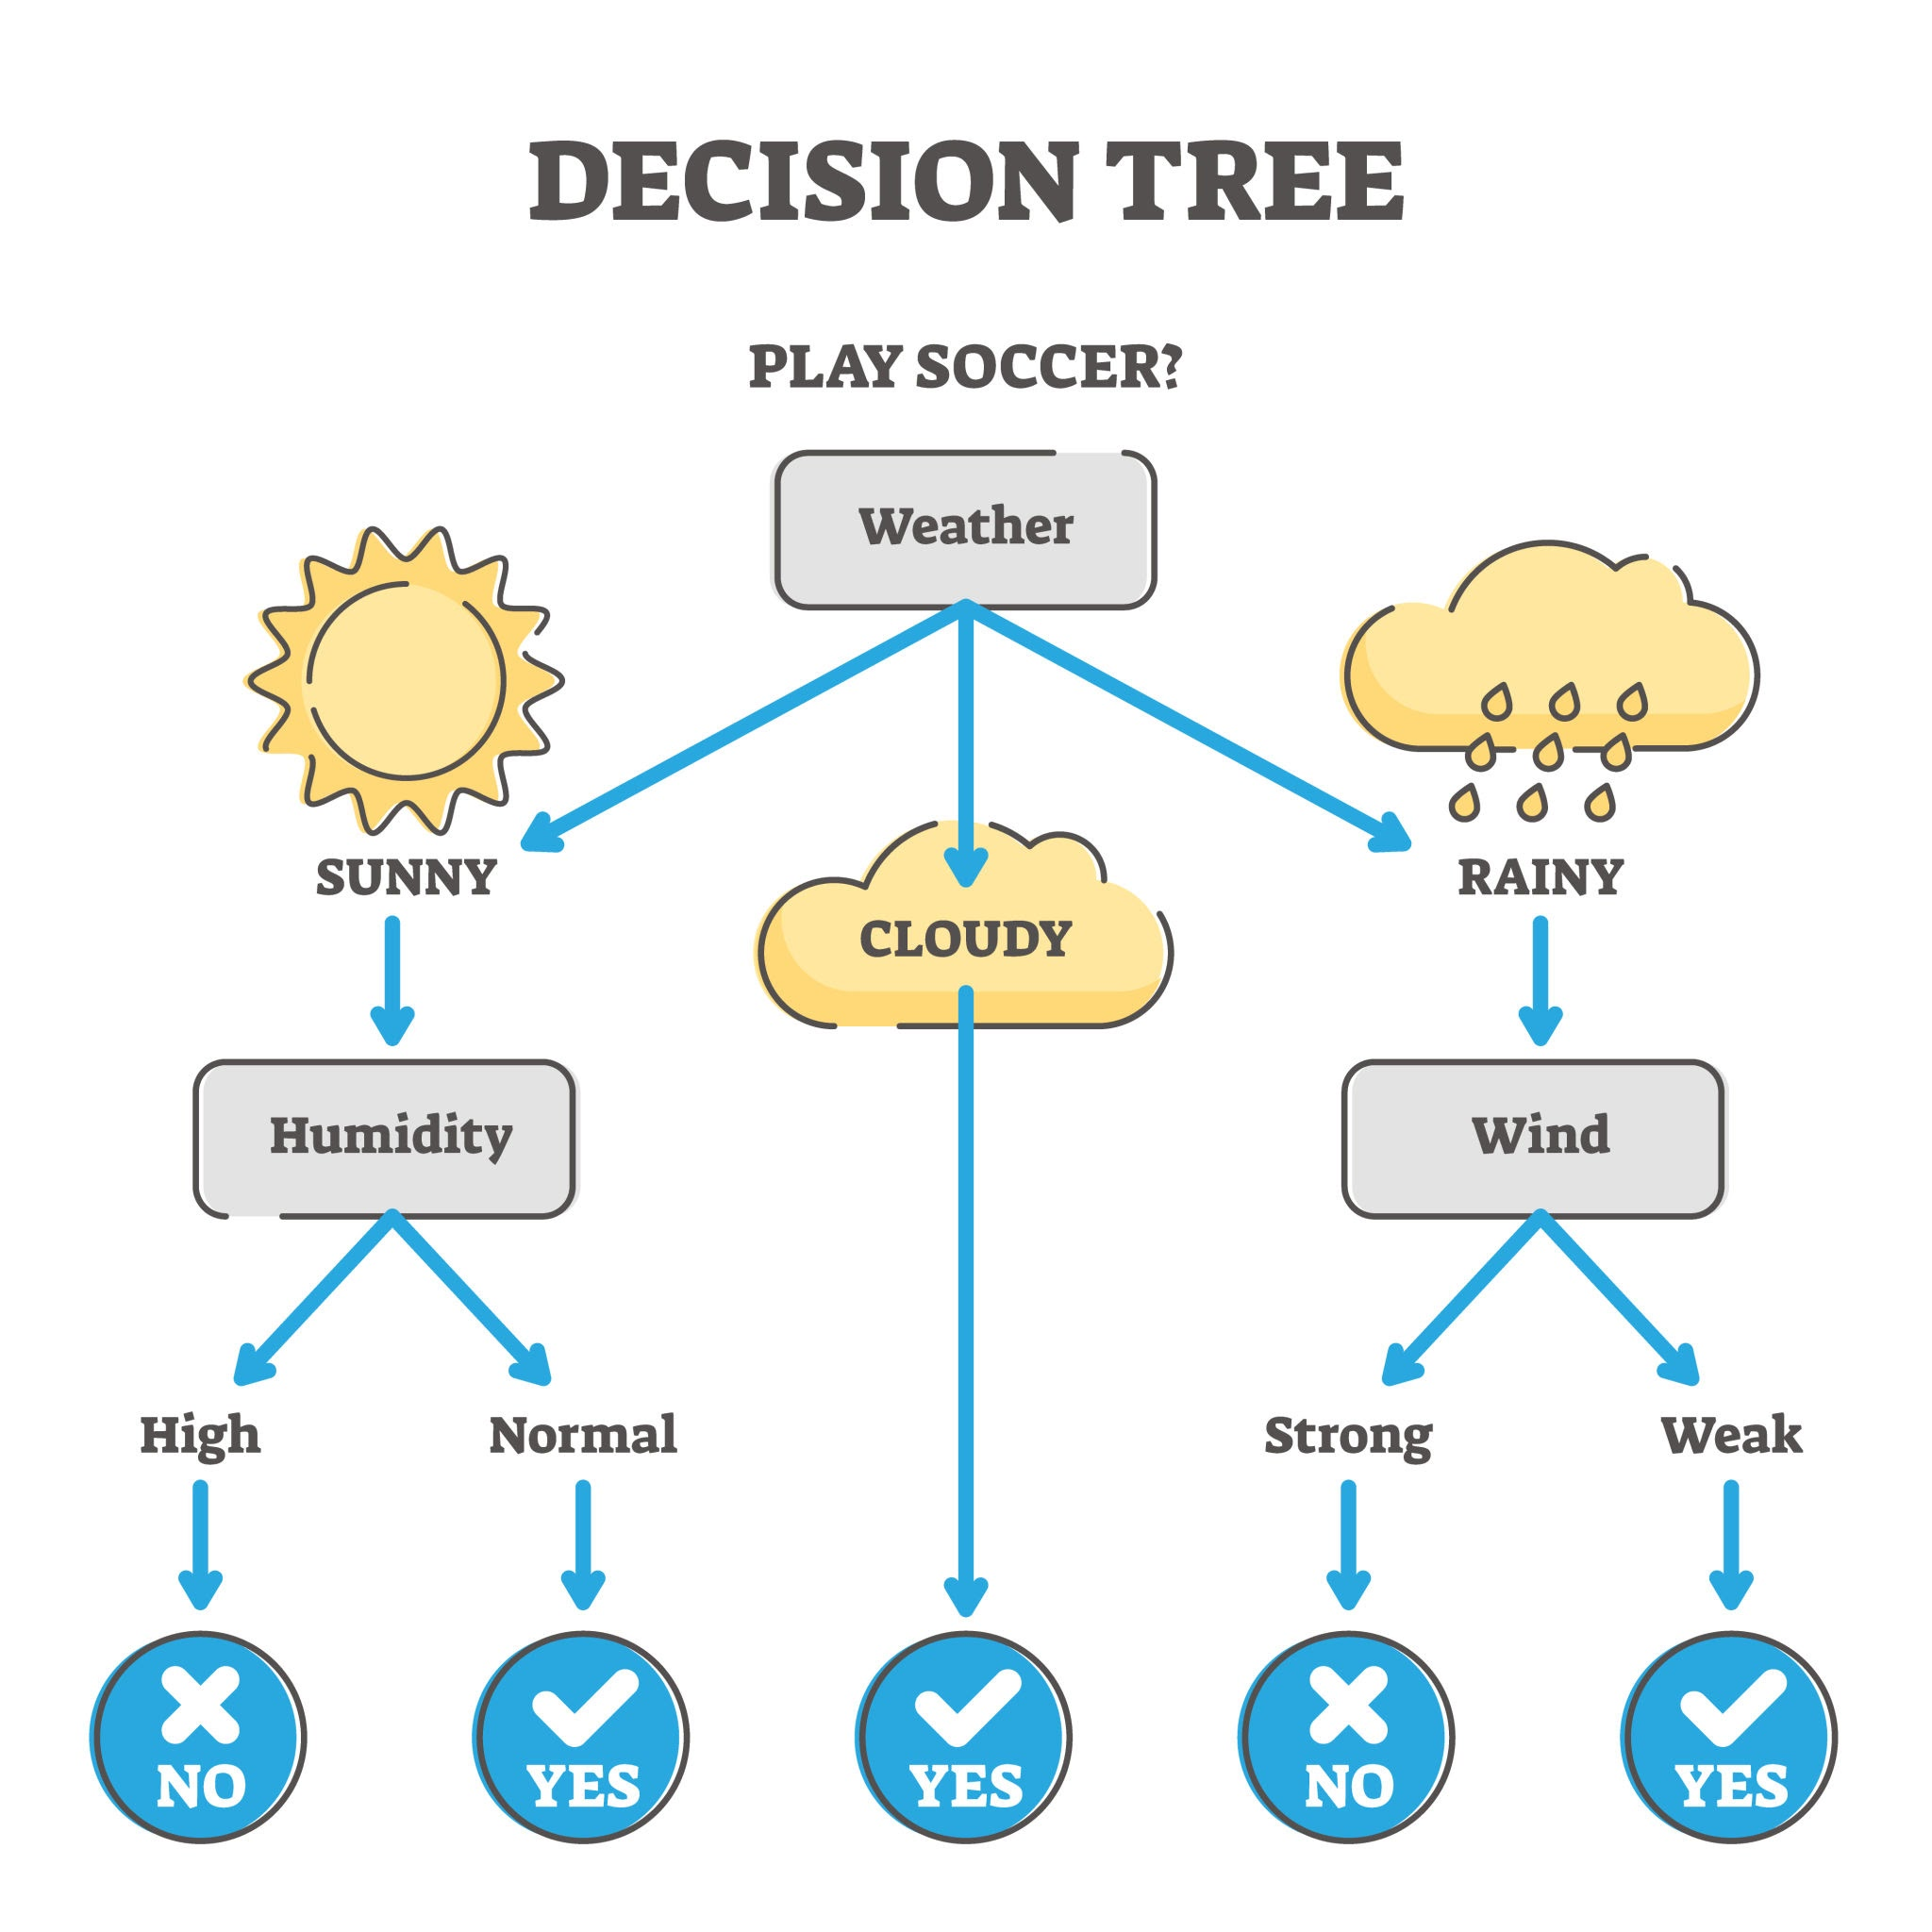

**How It Works: The Splitting Process**
The algorithm builds the tree in a greedy, top-down, recursive manner. At each internal node, it asks a "question" about a feature (e.g., "Is temperature > 25?"). The key is deciding which question to ask, or which feature to split on. The goal is to choose the split that creates the most "pure" child nodes.

Purity refers to how homogenous a node is with respect to the target variable. For a classification problem, a node is perfectly pure if all data points in it belong to the same class.

The algorithm uses impurity measures to evaluate potential splits:

**Gini Impurity**: A measure of how likely a randomly chosen element from a node would be incorrectly classified. A Gini score of 0 means perfect purity.

**Entropy**: A measure of the randomness or uncertainty of a node. A lower entropy indicates less randomness and higher purity. An entropy score of 0 means perfect purity.

The algorithm selects the split that results in the **maximum Information Gain**, which is the decrease in impurity after the split. This process is repeated until a stopping condition is met (e.g., a node is perfectly pure, a maximum depth is reached, or the number of samples in a node falls below a threshold).

### Decision Tree implementation from scratch

In [1]:
import numpy as np
from collections import Counter

# A simple helper class for each node in the tree
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value # This is the predicted class if the node is a leaf

    def is_leaf_node(self):
        """
        Checks if the node is a leaf node.
        """
        return self.value is not None

class DecisionTree:
    def __init__(self, min_samples_split=2, max_depth=100, n_features=None):
        """
        Initializes the DecisionTree classifier with hyperparameters.

        Args:
            min_samples_split (int): The minimum number of samples required to split a node.
            max_depth (int): The maximum depth of the tree.
            n_features (int): The number of features to consider at each split.
        """
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.n_features = n_features
        self.root = None # The root node of the tree

    def fit(self, X, y):
        """
        Builds the Decision Tree model.

        Args:
            X (np.ndarray): Training data features.
            y (np.ndarray): Target labels.
        """
        # Determine the number of features if not specified
        self.n_features = X.shape[1] if not self.n_features else min(X.shape[1], self.n_features)
        self.root = self._build_tree(X, y)

    def _build_tree(self, X, y, depth=0):
        """
        Recursively builds the tree by finding the best splits.
        """
        n_samples, n_feats = X.shape
        n_labels = len(np.unique(y))

        # Check for stopping criteria
        # 1. Node is perfectly pure (all samples belong to one class)
        # 2. Maximum depth is reached
        # 3. Minimum number of samples for a split is not met
        if (depth >= self.max_depth or n_labels == 1 or n_samples < self.min_samples_split):
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        # Find the best split
        best_feature_idx, best_threshold = self._best_split(X, y)

        # Create child nodes
        left_idxs = np.where(X[:, best_feature_idx] <= best_threshold)[0]
        right_idxs = np.where(X[:, best_feature_idx] > best_threshold)[0]

        left_child = self._build_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        right_child = self._build_tree(X[right_idxs, :], y[right_idxs], depth + 1)

        return Node(best_feature_idx, best_threshold, left_child, right_child)

    def _best_split(self, X, y):
        """
        Iterates through all features and finds the best split point
        that results in the lowest weighted Gini impurity.
        """
        best_gini = float('inf')
        split_idx, split_threshold = None, None

        for feature_idx in range(self.n_features):
            X_column = X[:, feature_idx]
            thresholds = np.unique(X_column)

            for threshold in thresholds:
                # Calculate Gini impurity for the current split
                left_y = y[X_column <= threshold]
                right_y = y[X_column > threshold]
                
                if len(left_y) == 0 or len(right_y) == 0:
                    continue

                n_left, n_right = len(left_y), len(right_y)
                n_total = len(y)

                gini_left = self._gini_impurity(left_y)
                gini_right = self._gini_impurity(right_y)

                # Calculate the weighted Gini impurity
                weighted_gini = (n_left / n_total) * gini_left + (n_right / n_total) * gini_right

                # Check if this is the best split so far
                if weighted_gini < best_gini:
                    best_gini = weighted_gini
                    split_idx = feature_idx
                    split_threshold = threshold

        return split_idx, split_threshold

    def _gini_impurity(self, y):
        """
        Calculates the Gini impurity for a given set of labels.
        """
        _, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        return 1 - np.sum(probabilities**2)

    def _most_common_label(self, y):
        """
        Finds the most common label in a dataset (for leaf nodes).
        """
        counter = Counter(y)
        most_common = counter.most_common(1)[0][0]
        return most_common

    def predict(self, X):
        """
        Predicts the class labels for a given set of data.
        """
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        """
        Traverses the tree to find a leaf node and its prediction.
        """
        if node.is_leaf_node():
            return node.value

        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        else:
            return self._traverse_tree(x, node.right)


# --- Putting it all together: A simple classification example ---
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Generate synthetic classification data
X, y = make_blobs(n_samples=500, centers=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Instantiate and train the model
model = DecisionTree(max_depth=5)
model.fit(X_train, y_train)

# 3. Make predictions on the test set
y_pred = model.predict(X_test)

# 4. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")


Model Accuracy: 100.00%


### 4\. Evaluation and Improvement of Decision Trees 📈

Evaluating and improving a Decision Tree is a bit different from Linear Regression because trees are non-parametric and more prone to **overfitting**. A key part of an interview is showing you know how to manage this.

#### A. Evaluation Metrics

For a classification task, we use different metrics than for regression:

1.  **Accuracy:** The most straightforward metric, measuring the percentage of correctly predicted instances.
    $$Accuracy = \frac{Number \: of \: Correct \: Predictions}{Total \: Number \: of \: Predictions}$$

2.  **Precision:** Of all the instances we predicted as positive, how many were actually positive? This is important when the cost of a false positive is high (e.g., a spam filter).
    $$Precision = \frac{True \: Positives}{True \: Positives + False \: Positives}$$

3.  **Recall (Sensitivity):** Of all the instances that were actually positive, how many did we correctly identify? This is important when the cost of a false negative is high (e.g., cancer detection).
    $$Recall = \frac{True \: Positives}{True \: Positives + False \: Negatives}$$

4.  **F1-Score:** The harmonic mean of Precision and Recall. It provides a single score that balances both metrics, which is useful when there's an uneven class distribution.
    $$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

5.  **ROC Curve and AUC:** The **Receiver Operating Characteristic (ROC)** curve plots the True Positive Rate (Recall) against the False Positive Rate at various threshold settings. The **Area Under the Curve (AUC)** measures the entire area underneath the ROC curve. A value of `1` indicates a perfect classifier, while `0.5` indicates a useless one. This is a very common metric for interviewers.

Here's how to calculate these using scikit-learn:

```python
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Assuming y_test and y_pred from the scikit-learn example
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# You can also get a classification report that summarizes these metrics
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# For AUC, you need the probabilities, not the final class predictions
y_probs = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_probs)
print(f"ROC AUC Score: {roc_auc:.2f}")
```

-----

#### B. Improving the Model: The Overfitting Problem

Decision Trees are notorious for **overfitting** because they can grow to be very deep and perfectly fit the training data's noise. The key to improving them is to prevent this.

  * **Pruning:** This is the process of removing sub-nodes of a decision tree. It can be done during or after the tree is built.

      * **Pre-Pruning:** Stop the tree's growth early. This is done by setting **hyperparameters** like `max_depth`, `min_samples_split`, and `min_samples_leaf` before training.
      * **Post-Pruning:** Allow the tree to grow to its full depth, then remove branches that don't contribute much to accuracy on a validation set. Scikit-learn doesn't directly support post-pruning, but it's a common concept to know.

  * **Hyperparameter Tuning:** You can use methods like **Grid Search** or **Random Search** to find the optimal values for the pruning hyperparameters.

  * **Ensemble Methods:** The most powerful way to improve Decision Trees is to use them as building blocks for more advanced models like **Random Forests** and **XGBoost**. These models combine multiple trees to reduce the high variance of a single tree, which we will cover next.

This concludes our deep dive into Decision Trees. You've now seen the theory, from-scratch implementation, library usage, and evaluation/improvement techniques.

Ready to move on to the next algorithm, **Random Forests**?